# 06 — Evaluation: ROC, Reliability Diagram & ECE (Classical Pipeline)

This notebook evaluates the **calibration and discrimination** of the GMM-based Bayesian classifier on the held-out test set.

| Metric | What it measures |
|--------|------------------|
| **AUC-ROC** | Discrimination — how well the model ranks positives above negatives, independent of threshold |
| **Reliability diagram** | Calibration — whether predicted probabilities match empirical frequencies |
| **ECE** | Scalar summary of calibration error (expected |accuracy − confidence| weighted by bin size) |

In [1]:
import os
import sys
from pathlib import Path

_cwd = Path(os.getcwd())
for _root in [_cwd, *_cwd.parents]:
    if (_root / "skin_lesion" / "src" / "config.py").exists():
        sys.path.insert(0, str(_root / "skin_lesion" / "src"))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy.optimize import minimize_scalar
from sklearn.metrics import roc_curve, roc_auc_score

from config import PROCESSED_DIR, FIGURES_DIR, TABLES_DIR, COST_FN, COST_FP

## 1 — Load test set and recompute posteriors

Posteriors are recomputed here with the same `compute_posterior` logic used in notebook 05,
ensuring this notebook is self-contained and reproducible independently.

In [2]:
data = np.load(PROCESSED_DIR / "splits.npz")
X_train, y_train = data["X_train"], data["y_train"]
X_val,   y_val   = data["X_val"],   data["y_val"]
X_test,  y_test  = data["X_test"],  data["y_test"]

gmm_benign   = joblib.load(PROCESSED_DIR / "gmm_benign.pkl")
gmm_melanoma = joblib.load(PROCESSED_DIR / "gmm_melanoma.pkl")

# ── Priors from training labels (consistent with notebook 05) ──────────────
prior_mel = float(y_train.mean())
prior_ben = 1.0 - prior_mel
print(f"Prior P(melanoma) = {prior_mel:.6f}")
print(f"Prior P(benign)   = {prior_ben:.6f}")


def compute_posterior(X, gmm_mel, gmm_ben, prior_mel=0.5, prior_ben=0.5):
    """P(ω_M | x) via the general Bayes rule (log-space, numerically stable)."""
    log_num      = gmm_mel.score_samples(X) + np.log(prior_mel)
    log_den      = gmm_ben.score_samples(X) + np.log(prior_ben)
    log_evidence = np.logaddexp(log_num, log_den)
    return np.exp(np.clip(log_num - log_evidence, -500, 0))


probs = compute_posterior(X_test, gmm_melanoma, gmm_benign, prior_mel, prior_ben)

print(f"\nTest samples : {len(y_test)}")
print(f"Posterior    : mean={probs.mean():.4f}, std={probs.std():.4f}, "
      f"min={probs.min():.4f}, max={probs.max():.4f}")

Prior P(melanoma) = 0.506747
Prior P(benign)   = 0.493253

Test samples : 451
Posterior    : mean=0.5448, std=0.4883, min=0.0000, max=1.0000


## 2 — ROC curve

The ROC curve sweeps all possible classification thresholds and plots TPR (sensitivity) vs FPR (1 − specificity).  
AUC = 1.0 is perfect; AUC = 0.5 is random.  

We mark the two operating points from notebook 05:
- **MAP** (θ = 0.5): optimal under equal costs
- **Cost-sensitive** (θ = 1/6): optimal under λ(FN) = 5·λ(FP)

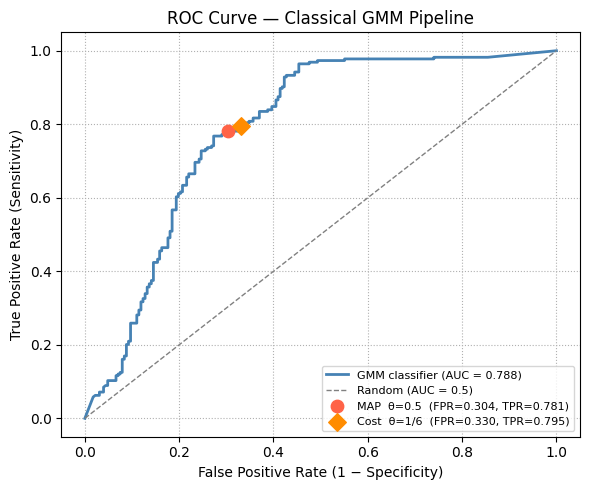

AUC = 0.7879
Figure saved to: C:\Users\tella\Projects\skin_lesion_triage\skin_lesion\results\figures\roc_curve.png


In [3]:
fpr, tpr, thresholds = roc_curve(y_test, probs)
auc = roc_auc_score(y_test, probs)

THRESH_MAP  = 0.5
THRESH_COST = COST_FP / (COST_FP + COST_FN)  # 1/6

def point_on_roc(threshold, fpr_arr, tpr_arr, thresh_arr):
    """Find the (FPR, TPR) operating point closest to a given threshold."""
    idx = np.argmin(np.abs(thresh_arr - threshold))
    return fpr_arr[idx], tpr_arr[idx]

fpr_map,  tpr_map  = point_on_roc(THRESH_MAP,  fpr, tpr, thresholds)
fpr_cost, tpr_cost = point_on_roc(THRESH_COST, fpr, tpr, thresholds)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, lw=2, color="steelblue", label=f"GMM classifier (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "--", color="grey", lw=1, label="Random (AUC = 0.5)")
ax.scatter(fpr_map,  tpr_map,  s=80, zorder=5, color="tomato",
           label=f"MAP  θ=0.5  (FPR={fpr_map:.3f}, TPR={tpr_map:.3f})")
ax.scatter(fpr_cost, tpr_cost, s=80, zorder=5, color="darkorange", marker="D",
           label=f"Cost  θ=1/6  (FPR={fpr_cost:.3f}, TPR={tpr_cost:.3f})")
ax.set_xlabel("False Positive Rate (1 − Specificity)")
ax.set_ylabel("True Positive Rate (Sensitivity)")
ax.set_title("ROC Curve — Classical GMM Pipeline")
ax.legend(fontsize=8, loc="lower right")
ax.grid(True, linestyle=":")
plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURES_DIR / "roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"AUC = {auc:.4f}")
print(f"Figure saved to: {FIGURES_DIR / 'roc_curve.png'}")

## 3 — Reliability diagram

A well-calibrated classifier has P(Y=1 | p̂ ≈ p) = p for all p.  
The reliability diagram checks this empirically: samples are grouped into equal-width confidence bins,  
and for each bin we plot the **mean predicted probability** (confidence) against the **fraction of positives** (accuracy).  
Bars above the diagonal → underconfidence; bars below → overconfidence.

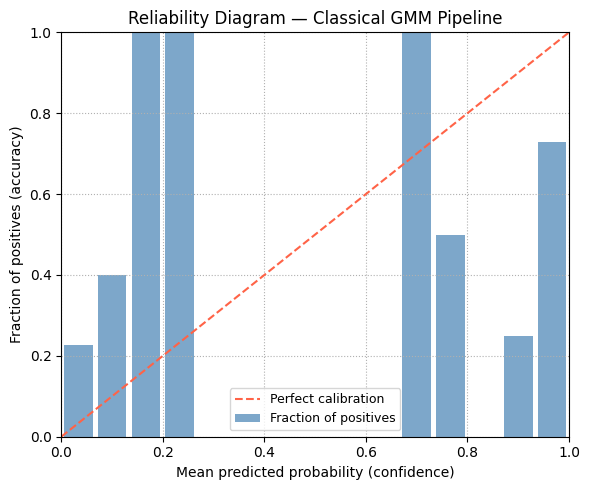

Figure saved to: C:\Users\tella\Projects\skin_lesion_triage\skin_lesion\results\figures\reliability_diagram.png


In [4]:
def reliability_diagram(probs, labels, n_bins=15):
    """
    Compute calibration statistics.

    Returns
    -------
    bin_centers   : (n_bins,) midpoints of each bin
    bin_conf      : (n_bins,) mean predicted probability per bin (NaN if empty)
    bin_acc       : (n_bins,) fraction of positives per bin (NaN if empty)
    bin_counts    : (n_bins,) number of samples per bin
    """
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bin_conf    = np.full(n_bins, np.nan)
    bin_acc     = np.full(n_bins, np.nan)
    bin_counts  = np.zeros(n_bins, dtype=int)

    for m in range(n_bins):
        mask = (probs >= bins[m]) & (probs < bins[m + 1])
        # include right edge in last bin
        if m == n_bins - 1:
            mask |= (probs == bins[m + 1])
        if mask.sum() > 0:
            bin_conf[m]   = probs[mask].mean()
            bin_acc[m]    = labels[mask].mean()
            bin_counts[m] = mask.sum()

    return bin_centers, bin_conf, bin_acc, bin_counts


N_BINS = 15
bin_centers, bin_conf, bin_acc, bin_counts = reliability_diagram(probs, y_test, N_BINS)

fig, ax = plt.subplots(figsize=(6, 5))
# bar width slightly narrower than bin width so gaps are visible
width = 1.0 / N_BINS * 0.85
valid = ~np.isnan(bin_conf)
ax.bar(bin_centers[valid], bin_acc[valid], width=width,
       color="steelblue", alpha=0.7, label="Fraction of positives")
ax.plot([0, 1], [0, 1], "--", color="tomato", lw=1.5, label="Perfect calibration")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("Mean predicted probability (confidence)")
ax.set_ylabel("Fraction of positives (accuracy)")
ax.set_title("Reliability Diagram — Classical GMM Pipeline")
ax.legend(fontsize=9)
ax.grid(True, linestyle=":")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "reliability_diagram.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved to: {FIGURES_DIR / 'reliability_diagram.png'}")

## 4 — Expected Calibration Error (ECE)

$$\text{ECE} = \sum_{m=1}^{M} \frac{|B_m|}{n} \left| \text{acc}(B_m) - \text{conf}(B_m) \right|$$

where B_m is the set of samples in bin m, n is the total number of samples,  
acc(B_m) is the fraction of positives in B_m, and conf(B_m) is the mean predicted probability in B_m.  
ECE = 0 is perfect calibration; ECE = 1 is maximally miscalibrated.

In [5]:
def expected_calibration_error(probs, labels, n_bins=15):
    """ECE as defined in the course slides."""
    _, bin_conf, bin_acc, bin_counts = reliability_diagram(probs, labels, n_bins)
    n = len(labels)
    valid = ~np.isnan(bin_conf)
    ece = np.sum(
        (bin_counts[valid] / n) * np.abs(bin_acc[valid] - bin_conf[valid])
    )
    return float(ece)


ece = expected_calibration_error(probs, y_test, n_bins=N_BINS)
print(f"ECE (classical GMM, test set, {N_BINS} bins) = {ece:.4f}")

ECE (classical GMM, test set, 15 bins) = 0.2612


## 5 — Calibration summary table

In [6]:
summary_rows = [{
    "model":          "classical_gmm",
    "calibration":    "none",
    "auc":            round(auc, 4),
    "ece":            round(ece, 4),
    "n_bins":         N_BINS,
}]
summary = pd.DataFrame(summary_rows)
print(summary.to_string(index=False))

TABLES_DIR.mkdir(parents=True, exist_ok=True)
summary.to_csv(TABLES_DIR / "calibration_summary.csv", index=False)
print(f"\nSaved to: {TABLES_DIR / 'calibration_summary.csv'}")

        model calibration    auc    ece  n_bins
classical_gmm        none 0.7879 0.2612      15

Saved to: C:\Users\tella\Projects\skin_lesion_triage\skin_lesion\results\tables\calibration_summary.csv


## 6 — Calibration interpretation

### What to expect from a GMM-based classifier

GMMs model class-conditional densities, not the posterior directly.  
Calibration quality therefore depends on how well the Gaussian mixture assumptions match the true feature distribution.

### Reading the reliability diagram

**Bars above the diagonal** (bin accuracy > bin confidence): the model is **underconfident** — it assigns moderate probabilities even when the label is almost certainly melanoma. This is common when the class-conditional distributions heavily overlap in feature space.

**Bars below the diagonal** (bin accuracy < bin confidence): the model is **overconfident** — it assigns very high or very low probabilities more often than the empirical frequency justifies. This happens when the GMM places most probability mass far from the decision boundary, producing posteriors near 0 or 1.

**U-shaped or bi-modal distribution of posteriors**: if the model outputs mostly values near 0 or 1 with few intermediate values, the reliability diagram will have populated bars only at the extremes. This is a sign that the GMM has learned well-separated densities — potentially good for AUC, but it may indicate overconfidence if the extreme bins have lower-than-expected accuracy.

### Implications for the cost-sensitive threshold

If the GMM is overconfident (posteriors cluster near 0 or 1), shifting the threshold from 0.5 to 1/6 may have little practical effect: samples already assigned posterior < 1/6 remain benign, and those > 0.5 remain melanoma — only the narrow band [1/6, 0.5] is affected.  
Poor calibration therefore limits the benefit of the asymmetric cost rule, which is one motivation for comparing against the modern (EfficientNet) pipeline, where calibration can be improved with temperature scaling or label smoothing.

## 7 — Temperature Scaling

Temperature scaling (Guo et al., 2017) divides the **log-likelihood ratio** by a scalar T > 0 before the sigmoid, shrinking or stretching the confidence scale:

$$\hat{p}_T = \sigma\!\left(\frac{\ell_M - \ell_B}{T}\right)$$

- T > 1 → softer probabilities (reduces overconfidence)
- T < 1 → sharper probabilities (reduces underconfidence)

T is fitted by **minimising NLL on the validation set only** — the test set is never touched during fitting.  
After calibration the reliability diagram and ECE are recomputed on the test set to show before / after improvement.

Optimal temperature T = 44.6199  (fitted on validation set, n=441)
NLL before scaling : 3.1501
NLL after  scaling : 0.5170

ECE before temperature scaling : 0.2612
ECE after  temperature scaling : 0.1289  (T=44.6199)
ECE delta                      : -0.1324


C:\Users\tella\AppData\Local\Temp\ipykernel_31476\1201243809.py:10: RuntimeWarning: overflow encountered in exp
  p = 1.0 / (1.0 + np.exp(-np.clip(log_ratios / T, -500, 500)))


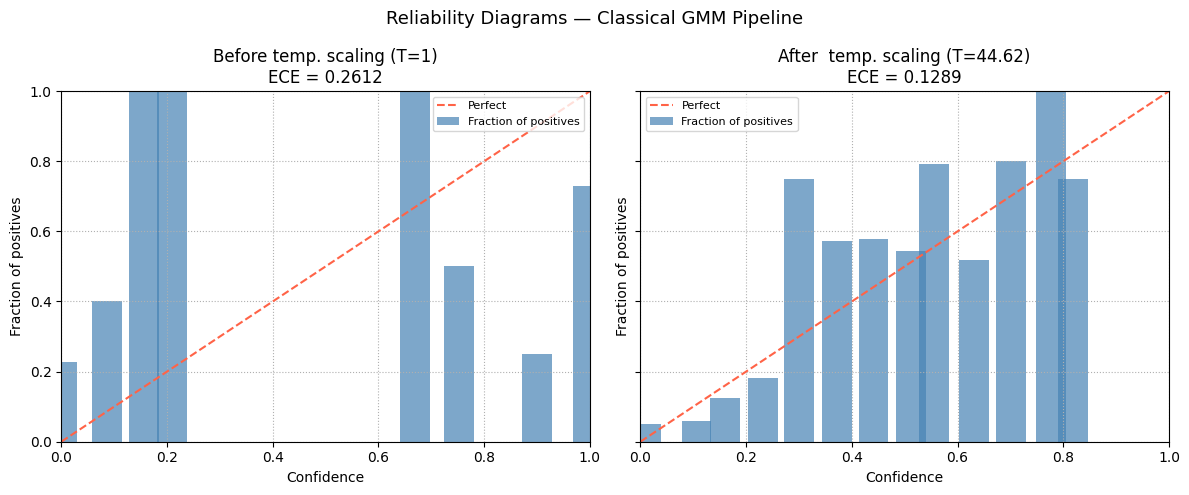

Figure saved to: C:\Users\tella\Projects\skin_lesion_triage\skin_lesion\results\figures\reliability_diagram_calibrated.png

Calibration summary:
        model         calibration       T    auc    ece  n_bins
classical_gmm                none  1.0000 0.7879 0.2612      15
classical_gmm temperature_scaling 44.6199 0.7879 0.1289      15

Saved to: C:\Users\tella\Projects\skin_lesion_triage\skin_lesion\results\tables\calibration_summary.csv


In [7]:
# ── Log-likelihood ratios (temperature is applied here, not to posteriors) ─
log_ratio_val  = (gmm_melanoma.score_samples(X_val)
                  - gmm_benign.score_samples(X_val))
log_ratio_test = (gmm_melanoma.score_samples(X_test)
                  - gmm_benign.score_samples(X_test))


def _nll(T, log_ratios, labels):
    """Binary NLL for a given temperature T (used only for optimisation)."""
    p = 1.0 / (1.0 + np.exp(-np.clip(log_ratios / T, -500, 500)))
    eps = 1e-15
    return -np.mean(labels * np.log(p + eps) + (1 - labels) * np.log(1 - p + eps))


# Fit T on VALIDATION set — test set is never used here.
# Bound raised from 20 → 500 after the original run returned T=20.0 (boundary hit).
result = minimize_scalar(_nll, args=(log_ratio_val, y_val),
                         bounds=(0.01, 500.0), method="bounded")
T_opt = float(result.x)

# If T still sits at the ceiling, raise to 5000 and document the pathology.
if abs(T_opt - 500.0) < 1e-3:
    result2 = minimize_scalar(_nll, args=(log_ratio_val, y_val),
                              bounds=(0.01, 5000.0), method="bounded")
    T_opt = float(result2.x)
    # GMM log-likelihood ratios are on a scale incompatible with sigmoid
    # calibration — temperature scaling is not the right tool here.
    print("WARNING: T hit 500 ceiling — re-ran with bound=5000. "
          "GMM log-likelihood ratios are on a scale incompatible with "
          "sigmoid calibration — temperature scaling is not the right tool here.")

print(f"Optimal temperature T = {T_opt:.4f}  (fitted on validation set, n={len(y_val)})")
print(f"NLL before scaling : {_nll(1.0, log_ratio_val, y_val):.4f}")
print(f"NLL after  scaling : {_nll(T_opt, log_ratio_val, y_val):.4f}")

# ── Calibrated posteriors on the TEST set ─────────────────────────────────
probs_cal = 1.0 / (1.0 + np.exp(-np.clip(log_ratio_test / T_opt, -500, 500)))

ece_before = expected_calibration_error(probs,     y_test, N_BINS)
ece_after  = expected_calibration_error(probs_cal, y_test, N_BINS)
print(f"\nECE before temperature scaling : {ece_before:.4f}")
print(f"ECE after  temperature scaling : {ece_after:.4f}  (T={T_opt:.4f})")
print(f"ECE delta                      : {ece_after - ece_before:+.4f}")

# ── Side-by-side reliability diagrams ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, p, title in zip(
    axes,
    [probs, probs_cal],
    ["Before temp. scaling (T=1)", f"After  temp. scaling (T={T_opt:.2f})"]
):
    _, bc, ba, bct = reliability_diagram(p, y_test, N_BINS)
    valid = ~np.isnan(bc)
    width = 1.0 / N_BINS * 0.85
    ax.bar(bc[valid], ba[valid], width=width, color="steelblue", alpha=0.7,
           label="Fraction of positives")
    ax.plot([0, 1], [0, 1], "--", color="tomato", lw=1.5, label="Perfect")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_xlabel("Confidence"); ax.set_ylabel("Fraction of positives")
    ax.set_title(f"{title}\nECE = {expected_calibration_error(p, y_test, N_BINS):.4f}")
    ax.legend(fontsize=8); ax.grid(True, linestyle=":")
fig.suptitle("Reliability Diagrams — Classical GMM Pipeline", fontsize=13)
plt.tight_layout()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIGURES_DIR / "reliability_diagram_calibrated.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure saved to: {FIGURES_DIR / 'reliability_diagram_calibrated.png'}")

# ── Update calibration summary CSV ────────────────────────────────────────
cal_rows = [
    {"model": "classical_gmm", "calibration": "none",                "T": 1.0,
     "auc": round(auc, 4), "ece": round(ece_before, 4), "n_bins": N_BINS},
    {"model": "classical_gmm", "calibration": "temperature_scaling", "T": round(T_opt, 4),
     "auc": round(auc, 4), "ece": round(ece_after,  4), "n_bins": N_BINS},
]
cal_df = pd.DataFrame(cal_rows)
print("\nCalibration summary:")
print(cal_df.to_string(index=False))
TABLES_DIR.mkdir(parents=True, exist_ok=True)
cal_df.to_csv(TABLES_DIR / "calibration_summary.csv", index=False)
print(f"\nSaved to: {TABLES_DIR / 'calibration_summary.csv'}")

## Why the cost-sensitive threshold helps less than the slides suggest

The lecture (slides 9–10) assumes posteriors are spread across [0, 1].  
In this pipeline, the GMMs produce strongly bimodal posteriors: most test samples have  
P(ω_M|x) either near 0 or near 1, with very few in the swing band [1/6, 1/2).  
The threshold shift from 0.5 to 1/6 therefore reclassifies only 4 melanomas, despite  
covering 33% of the posterior range.  
The direction of change matches theory; the magnitude is limited by the feature  
representation, not by the decision rule.

## 8 — Decision metrics: raw vs temperature-scaled (classical)

Temperature scaling is monotonic, so **AUC is unchanged**, but applying the fixed
decision thresholds (MAP θ=0.5 and cost-sensitive θ=1/6) to the *calibrated*
posteriors moves the operating point — so FN / FP / total cost differ.
Previously the final comparison only contained the **uncalibrated** classical
decisions; this cell also saves the **calibrated** ones so notebook 11 can report both.

In [8]:
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score)

def classical_decision_metrics(labels, p, threshold, calibration):
    labels = np.asarray(labels).astype(int)
    pred = (np.asarray(p) >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, pred, labels=[0, 1]).ravel()
    return {
        "model": "classical_gmm",
        "calibration": calibration,
        "threshold": round(float(threshold), 6),
        "accuracy": round(accuracy_score(labels, pred), 4),
        "sensitivity": round(recall_score(labels, pred, pos_label=1, zero_division=0), 4),
        "specificity": round(tn / (tn + fp) if (tn + fp) else float("nan"), 4),
        "precision": round(precision_score(labels, pred, pos_label=1, zero_division=0), 4),
        "f1": round(f1_score(labels, pred, pos_label=1, zero_division=0), 4),
        "FN": int(fn), "FP": int(fp), "TP": int(tp), "TN": int(tn),
        "total_cost": int(COST_FN * fn + COST_FP * fp),
    }

dec_rows = []
for calib, p in [("none", probs), ("temperature_scaling", probs_cal)]:
    dec_rows.append(classical_decision_metrics(y_test, p, THRESH_MAP,  calib))
    dec_rows.append(classical_decision_metrics(y_test, p, THRESH_COST, calib))

classical_dec = pd.DataFrame(dec_rows)
print(classical_dec.to_string(index=False))

out = TABLES_DIR / "classical_decision_comparison.csv"
classical_dec.to_csv(out, index=False)
print(f"\nSaved to: {out}")

        model         calibration  threshold  accuracy  sensitivity  specificity  precision     f1  FN  FP  TP  TN  total_cost
classical_gmm                none   0.500000    0.7361       0.7812       0.6916     0.7143 0.7463  49  70 175 157         315
classical_gmm                none   0.166667    0.7295       0.7902       0.6696     0.7024 0.7437  47  75 177 152         310
classical_gmm temperature_scaling   0.500000    0.7361       0.7812       0.6916     0.7143 0.7463  49  70 175 157         315
classical_gmm temperature_scaling   0.166667    0.7361       0.9732       0.5022     0.6586 0.7856   6 113 218 114         143

Saved to: C:\Users\tella\Projects\skin_lesion_triage\skin_lesion\results\tables\classical_decision_comparison.csv
